In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'

# Class number setting

In [3]:
NUM_CLASSES = 5

# Load training data

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model construction

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout (Dropout)                    │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │             860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │              55 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,125 (4.39 KB)

 Trainable params: 1,125 (4.39 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1719 - loss: 1.8718
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.1576 - loss: 1.8735 - val_accuracy: 0.2545 - val_loss: 1.6863
Epoch 2/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1562 - loss: 1.7715
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.1818 - loss: 1.7701 - val_accuracy: 0.2545 - val_loss: 1.6655
Epoch 3/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2266 - loss: 1.7619
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2121 - loss: 1.7745 - val_accuracy: 0.2364 - val_loss: 1.6471
Epoch 4/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1875 - loss: 1.7840
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.keras
2/2 ━━━━━━━━━━

In [12]:

val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7455 - loss: 0.9399


In [13]:

model = tf.keras.models.load_model(model_save_path)

In [14]:

predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[0.14523347 0.0198552  0.12254562 0.68039644 0.03196922]
3


# Confusion matrix

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


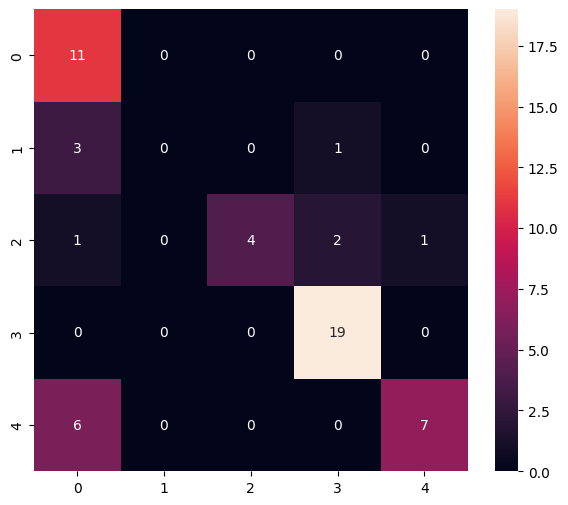

Classification Report
              precision    recall  f1-score   support

           0       0.52      1.00      0.69        11
           1       0.00      0.00      0.00         4
           2       1.00      0.50      0.67         8
           3       0.86      1.00      0.93        19
           4       0.88      0.54      0.67        13

    accuracy                           0.75        55
   macro avg       0.65      0.61      0.59        55
weighted avg       0.76      0.75      0.71        55



C:\Users\srush\Desktop\hand-gesture-recognition-mediapipe-main (1)\hand-gesture-recognition-mediapipe-main\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\srush\Desktop\hand-gesture-recognition-mediapipe-main (1)\hand-gesture-recognition-mediapipe-main\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\srush\Desktop\hand-gesture-recognition-mediapipe-main (1)\hand-gesture-recognition-mediapipe-main\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: Undefin

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to a TensorFlow Lite model

In [16]:

model.save(model_save_path, include_optimizer=False)

In [17]:

tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\srush\AppData\Local\Temp\tmpieqcq8oq\assets


INFO:tensorflow:Assets written to: C:\Users\srush\AppData\Local\Temp\tmpieqcq8oq\assets


Saved artifact at 'C:\Users\srush\AppData\Local\Temp\tmpieqcq8oq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1557646222800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1557646218576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1557646227408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1557646217616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1557646225104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1557646225872: TensorSpec(shape=(), dtype=tf.resource, name=None)


6600

# Inference Test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

C:\Users\srush\Desktop\hand-gesture-recognition-mediapipe-main (1)\hand-gesture-recognition-mediapipe-main\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [19]:

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[0.14523345 0.0198552  0.12254561 0.68039644 0.03196922]
3
